In [20]:
import pandas as pd

# EDA
df = pd.read_csv('data/Telco-Customer-Churn-dataset.csv')
df.info()
df.isnull().sum()
df['Churn'].value_counts(normalize=False)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Churn
No     5174
Yes    1869
Name: count, dtype: int64

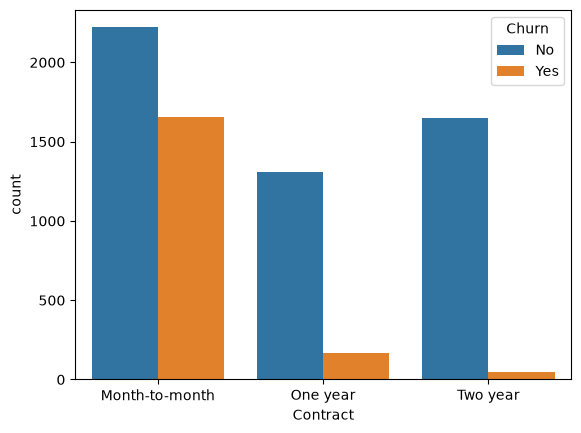

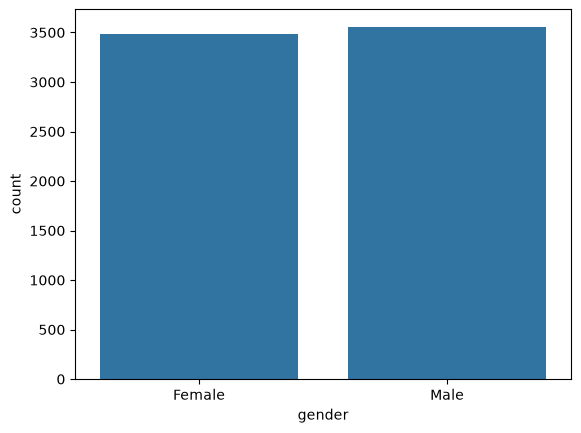

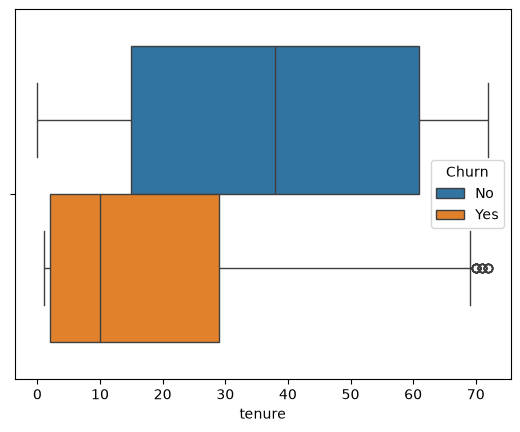

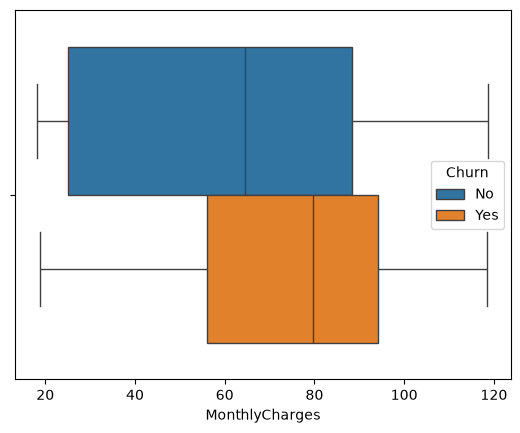

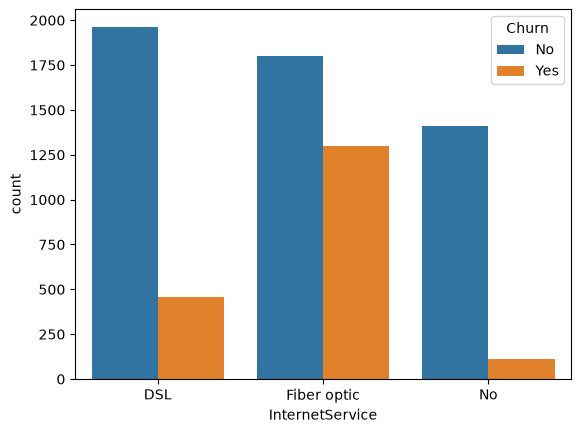

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Contract', hue='Churn')
plt.show()
sns.countplot(data=df, x='gender')
plt.show()
sns.boxplot(data=df, x='tenure', hue='Churn')
plt.show()
sns.boxplot(data=df, x='MonthlyCharges', hue='Churn')
plt.show()
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.show()

In [22]:
# Data cleaning
df['TotalCharges'].head()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isna().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df['TotalCharges'].isna().sum())

df = df.drop(columns='customerID')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


11
0


In [23]:
# Columns separated by type
num_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

cat_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]


In [24]:
# Feature engineering

df['tenure_group'] = pd.cut(
  df['tenure'],
  bins=[0, 12, 24, 48, 72],
  labels=['0-1y', '1-2y', '2-4y', '4-6y']
)

df['MonthlyCharges_group'] = pd.cut(
  df['MonthlyCharges'],
  bins= [0, 30, 60, 90, 120],
  labels= ['low', 'medium', 'high', 'very_high']
)

df['TotalCharges_group'] = pd.cut(
  df['TotalCharges'],
  bins= [0, 1450, 2900, 4350, 5800, 7250, 8700],    
  labels= ['very_low', 'low', 'medium', 'high', 'very_high', 'ultra_high']
)



In [25]:
# Preprocessing

from sklearn.compose import ColumnTransformer # allows different columns do different processing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
                                  # scale numbers | categories -> numbers

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

In [26]:
# Train/Test split

from sklearn.model_selection import train_test_split

X = df.drop(columns='Churn')
Y = df['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(
  X, Y,
  test_size=0.2,
  stratify=Y, # Save correlation for train Y and test Y set, as it is in initial data
  random_state=42
  )

In [ ]:
# Logistic Regression model training

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

LR_pipeline = Pipeline([
  ('preprocessor', preprocessor),
  ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
  #                                 model should have sufficient amount | Error on smaller class should have more weight
])

LR_pipeline.fit(X_train, Y_train)
LR_prediction = LR_pipeline.predict(X_test) # What model decided
LR_prediction_proba = LR_pipeline.predict_proba(X_test)[:, 1] # Gives probabilities [:, 1] - takes only second column Churn - YES
print(LR_prediction)
print(LR_prediction_proba)


[0 1 0 ... 0 0 0]
[0.11540138 0.85209628 0.14604102 ... 0.33629714 0.01338616 0.01765644]


              precision    recall  f1-score   support

           0      0.902     0.721     0.801      1035
           1      0.503     0.783     0.613       374

    accuracy                          0.737      1409
   macro avg      0.703     0.752     0.707      1409
weighted avg      0.796     0.737     0.751      1409

ROC-AUC: 0.8414063912785139


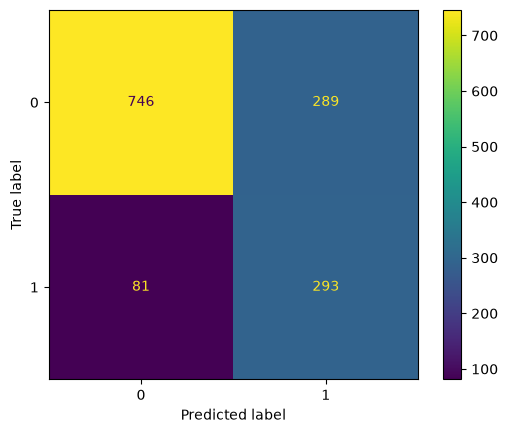

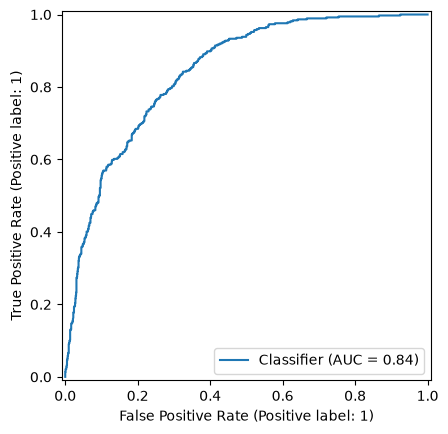

In [34]:
# Evaluation of the Logistic Regression model result

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

print(classification_report(Y_test, LR_prediction, digits=3))
print('ROC-AUC:', roc_auc_score(Y_test, LR_prediction_proba)) # How confident model separates the two classes (Churn/No churn) using different threshold; 0.5 - nearly random distinction; 1.0 - ideal distinction 
#

ConfusionMatrixDisplay.from_predictions(Y_test, LR_prediction)
RocCurveDisplay.from_predictions(Y_test, LR_prediction_proba)